# How to build a finite-element model in YaFEM

YaFEM (Yet another finite-element modeling toolbox) is a toolbox to create simple finite-element models made of 1D, 2D and 3D elements.

In the following, it is demonstrated how to build the finite-element model for a simple cantilever beam subjected to a vertical tip displacement and horizontal tip force.

<img src="assets\cantilever_beam.jpg" alt="Cantilever beam example" height="200">

Step 1: define model parameters

In [1]:
_l = 600.0 # length of the beam [mm]
_E = 210.0 # Young's modulus [kN/mm^2]

# cross-section parameters (see the sketch above)
_b = 40.0 # cross section width [mm]
_h = 60.0 # cross section height [mm]
_s = 5.0 # cross section thickness [mm]
_A = _b*_h - (_b-2*_s) * (_h-2*_s) # cross-section area [mm2]
_I = _b*_h**3/12 - (_b-2*_s)*(_h-2*_s)**3/12 # moment of inertia about x-axis [mm4]

# parameters of the applied boundary conditions (displacements and forces)
_uv = 5.0 # vertical displacement applied to node 2 [mm]
_fh = 1.0 # horizontal force applied to node 2 [kN]

Step 2: import YaFEM modules

In [2]:
from yafem.nodes import *
from yafem.elem import *
from yafem.model import *
from yafem.simulation import *

Step 3: create the FE model nodes

In [11]:
# nodal parameters
my_nodes_pars = {}
my_nodes_pars['nodal_data'] = np.array([[1,0.0,0.0,0.0],
                                        [2,_l,0.0,0.0]])

# create the node object
my_nodes = nodes(my_nodes_pars)

#my_nodes.plot()

Step 4: create the FE model elements

In [4]:
my_beam3d_pars = {}
my_beam3d_pars['E'] = _E
my_beam3d_pars['A'] = _A
my_beam3d_pars['I'] = _I
my_beam3d_pars['nodal_labels'] = [1,2] # nodes of the element

# create empty element list
my_elements = []

# append the single element of the model
my_elements.append(beam2d(my_nodes,my_beam3d_pars))

In [5]:
help(beam2d)

Help on class beam2d in module yafem.elem.beam2d:

class beam2d(yafem.elem.core_elem.core_elem)
 |  beam2d(my_nodes, pars)
 |
 |  my_nodes : nodes
 |
 |  pars: dictionary:
 |      A           : float,     cross-sectional area (default 200.0)
 |      I           : float,     second area moment (default 1000.0)
 |      E           : float,     Young's modulus (default 210e3)
 |      G           : float,     shear modulus (default 81e3)
 |      k0a         : float,     axial Winkler stiffness (default 0.0)
 |      k0b         : float,     lateral Winkler stiffness (default 0.0)
 |      rho         : float,     density (default 7850/1e9)
 |      fa          : float,     axial distributed force (default 0.0)
 |      fb          : float,     lateral distributed force (default 0.0)
 |      alpha       : float,     thermal expansion coefficient (default 0.0)
 |      theta       : float,     thermal loading (default 0.0)
 |      nodal_labels: list[int], node labels (default [1,2])
 |      dofs_

Step 5: create the FE model

array([[2, 1],
       [2, 2],
       [2, 3]])

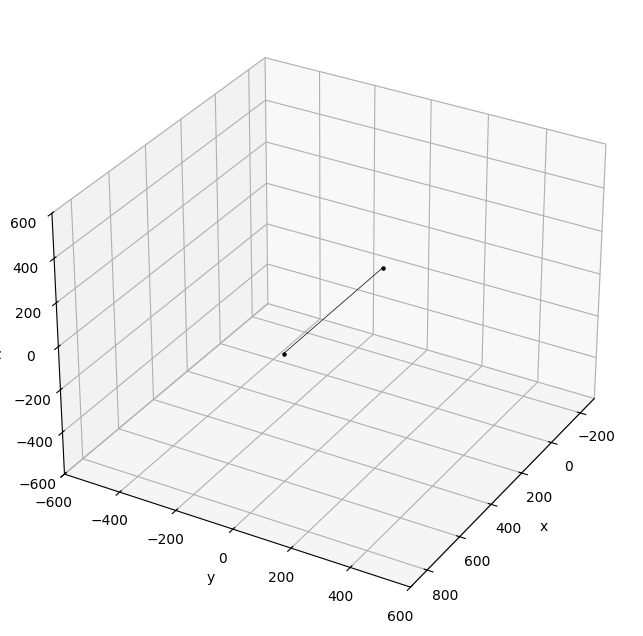

In [6]:
my_model_pars = {}

# constrained dofs
my_model_pars['dofs_c'] = np.array([[1,1], # x-displacements of node 1
                                    [1,2], # y-displacements of node 1
                                    [1,3]]) # z-rotation of node 1

# dofs applied forces
my_model_pars['dofs_f'] = np.array([[2,1]])

# dofs applied displacements
my_model_pars['dofs_u'] = np.array([[2,2]])

# number of steps for the simulation
_N = 21

# history of applied forces
my_model_pars['g_f'] = np.linspace(0,_fh,_N)

# history of applied displacements
my_model_pars['g_u'] = np.linspace(0,_uv,_N)

# crete the model
my_model = model(my_nodes,my_elements,my_model_pars)

my_model.plot()

my_model.dofs

Step 6: create and execute the simulation

In [7]:
# parameters of the simulation
my_simulation_pars = {}

# simulation object
my_simulation = simulation(my_model,my_simulation_pars)

# here I compute the static response of the cantilever beam to the applied forces/displacements
[u,l,r] = my_simulation.static_analysis()

step 1 converged in 1 iterations with residual 1.3261245094992054e-14
step 2 converged in 1 iterations with residual 7.093799214662443e-14
step 3 converged in 1 iterations with residual 2.985621112902596e-14
step 4 converged in 1 iterations with residual 2.0137802886889215e-16
step 5 converged in 1 iterations with residual 2.2680588834636704e-14
step 6 converged in 1 iterations with residual 4.0489770061820016e-14
step 7 converged in 1 iterations with residual 1.82829537108529e-14
step 8 converged in 1 iterations with residual 1.3333757774039194e-13
step 9 converged in 1 iterations with residual 1.0720032969466519e-13
step 10 converged in 1 iterations with residual 8.498625720287469e-14
step 11 converged in 1 iterations with residual 6.587575180138112e-14
step 12 converged in 1 iterations with residual 4.926185029370507e-14
step 13 converged in 1 iterations with residual 1.5028603444736292e-13
step 14 converged in 1 iterations with residual 1.9607269865574081e-13
step 15 converged in 1

Step 7: post-process the results

Text(0.5, 1.0, 'vertical displacement of node 2')

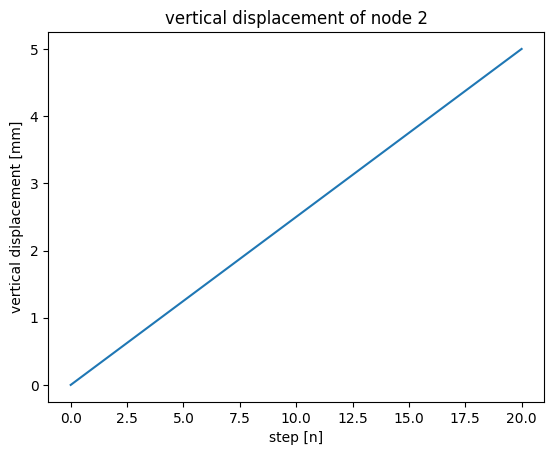

In [10]:
# this is how you extract the index of a dofs given its label (node and direction)
idx = my_model.find_dofs([[2,2]])

# plot the vertical displacement of the free end of the beam
plt.plot(u[idx,:].squeeze())
plt.xlabel('step [n]')
plt.ylabel('vertical displacement [mm]')
plt.title('vertical displacement of node 2')